In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from zoneinfo import ZoneInfo

In [2]:
# Step 1: Load the Dataset
apps_df = pd.read_csv(r"C:\Users\DELL\Pictures\elevance_skills\play_store_data\apps.csv")
reviews_df = pd.read_csv(r"C:\Users\DELL\Pictures\elevance_skills\play_store_data\user_reviews.csv")

In [3]:
apps_df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
time_data = apps_df.copy()

time_data["Last Updated"] = pd.to_datetime(
    time_data["Last Updated"],
    errors="coerce"
)

time_data = time_data.dropna(
    subset=["Last Updated"]
)

In [5]:
time_data = time_data[
    time_data["Reviews"] > 500
]

In [15]:
time_data["App"] = time_data["App"].astype(str)

# App should not start with X, Y, Z
time_data = time_data[
    ~time_data["App"]
    .str.upper()
    .str.startswith(("X", "Y", "Z"))
]

# App should not contain S
time_data = time_data[
    ~time_data["App"]
    .str.upper()
    .str.contains("S", na=False)
]

In [16]:
time_data["Category"] = time_data["Category"].astype(str)

time_data = time_data[
    time_data["Category"]
    .str.upper()
    .str.startswith(("E", "C", "B"))
]

In [17]:
category_translation = {
    "BEAUTY": "सौंदर्य",
    "BUSINESS": "வணிகம்",
    "DATING": "Dating"
}

time_data["Graph_Category"] = (
    time_data["Category"]
    .str.upper()
    .replace(category_translation)
)

In [18]:
time_data["Month"] = (
    time_data["Last Updated"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [28]:
# Convert Installs to numeric

time_data["Installs"] = (
    time_data["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

time_data["Installs"] = pd.to_numeric(
    time_data["Installs"],
    errors="coerce"
)


# Remove missing Installs
time_data = time_data.dropna(
    subset=["Installs"]
)


# Group total installs by Month and Category

monthly_data = (
    time_data
    .groupby(
        ["Month", "Graph_Category"]
    )["Installs"]
    .sum()
    .reset_index()
)


# Sort the data

monthly_data = monthly_data.sort_values(
    ["Graph_Category", "Month"]
)


monthly_data.head()

,Month,Graph_Category,Installs
5,2014-10-01,BOOKS_AND_REFERENCE,500000
6,2014-11-01,BOOKS_AND_REFERENCE,5000000
10,2015-07-01,BOOKS_AND_REFERENCE,10000000
18,2016-06-01,BOOKS_AND_REFERENCE,60000
21,2016-08-01,BOOKS_AND_REFERENCE,100000


In [29]:
# Calculate previous month installs

monthly_data["Previous_Installs"] = (
    monthly_data
    .groupby("Graph_Category")["Installs"]
    .shift(1)
)


# Calculate growth percentage

monthly_data["Growth_Percentage"] = (
    (
        monthly_data["Installs"]
        -
        monthly_data["Previous_Installs"]
    )
    /
    monthly_data["Previous_Installs"]
) * 100


monthly_data.head()

,Month,Graph_Category,Installs,Previous_Installs,Growth_Percentage
5,2014-10-01,BOOKS_AND_REFERENCE,500000,NaN,NaN
6,2014-11-01,BOOKS_AND_REFERENCE,5000000,500000.0,900.000000
10,2015-07-01,BOOKS_AND_REFERENCE,10000000,5000000.0,100.000000
18,2016-06-01,BOOKS_AND_REFERENCE,60000,10000000.0,-99.400000
21,2016-08-01,BOOKS_AND_REFERENCE,100000,60000.0,66.666667


C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\523638842.py:94: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\523638842.py:94: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\523638842.py:94: UserWarning: Glyph 2380 (\N{DEVANAGARI VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\523638842.py:94: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\523638842.py:94: UserWarning: Glyph 2342 (\N{DEVANAGARI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\523638842.py:94: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.


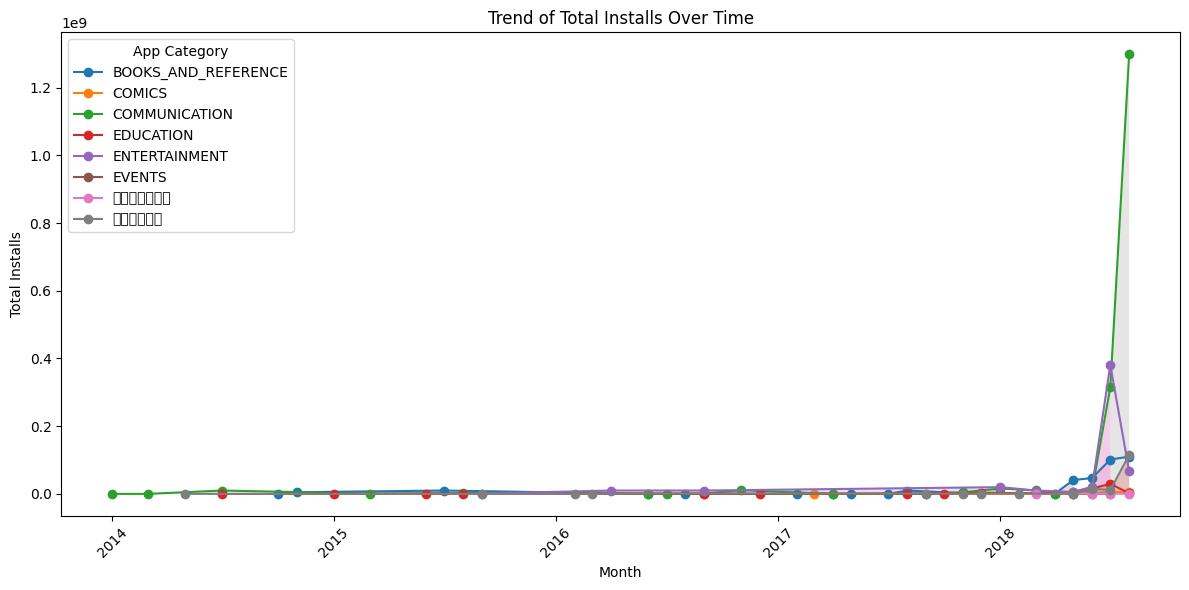

In [30]:
# Get current time in IST
india_time = datetime.now(
    ZoneInfo("Asia/Kolkata")
)

current_hour = india_time.hour


# Show graph only between 6 PM and 9 PM IST
if 18 <= current_hour < 21:

    plt.figure(figsize=(12, 6))


    # Get all categories
    categories = monthly_data[
        "Graph_Category"
    ].unique()


    # Plot each category
    for category in categories:

        category_data = monthly_data[
            monthly_data["Graph_Category"] == category
        ].reset_index(drop=True)


        # Plot line chart
        plt.plot(
            category_data["Month"],
            category_data["Installs"],
            marker="o",
            label=category
        )


        # Check growth greater than 20%
        for i in range(1, len(category_data)):

            growth = category_data.loc[
                i,
                "Growth_Percentage"
            ]


            # Shade area under curve
            # when growth is greater than 20%
            if pd.notna(growth) and growth > 20:

                plt.fill_between(
                    category_data.loc[
                        i - 1:i,
                        "Month"
                    ],
                    category_data.loc[
                        i - 1:i,
                        "Installs"
                    ],
                    alpha=0.2
                )


    # Graph title
    plt.title(
        "Trend of Total Installs Over Time"
    )


    # X-axis
    plt.xlabel(
        "Month"
    )


    # Y-axis
    plt.ylabel(
        "Total Installs"
    )


    # Show category names
    plt.legend(
        title="App Category"
    )


    # Rotate month names
    plt.xticks(
        rotation=45
    )


    plt.tight_layout()


    # Display graph below Jupyter cell
    plt.show()


else:

    print(
        "Graph is available only between "
        "6 PM IST and 9 PM IST."
    )